# Recommender Aggregate Pearson Heatmaps

This notebook follows the same run-discovery and artifact-loading pattern as `notebooks/recommender_evaluation_barplots.ipynb`, but it only visualizes aggregate Pearson results.

For each of `Pearson@3`, `Pearson@5`, and `Pearson@8`, it renders one heatmap with:
- x-axis = Dirichlet alpha
- y-axis = number of clients
- cell annotation = aggregate averages for `secure` and `clustered`, plus `plain` when enabled
- cell annotation also includes the share of clients where `clustered` outperformed `secure` for that Pearson metric
- cell color = mean of the displayed mode values in that cell


In [1]:
from __future__ import annotations

import json
import re
from datetime import datetime, timezone
from pathlib import Path

try:
    import matplotlib.colors as mcolors
    import matplotlib.pyplot as plt
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "matplotlib is required for this notebook. Install it in the active notebook environment."
    ) from exc

try:
    import numpy as np
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "numpy is required for this notebook. Install it in the active notebook environment."
    ) from exc

try:
    import pandas as pd
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "pandas is required for this notebook. Install it in the active notebook environment."
    ) from exc

from IPython.display import Markdown, display

plt.style.use("default")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)


In [2]:
candidate_roots = [Path.cwd(), Path.cwd().parent]
REPO_ROOT = next(
    (
        root
        for root in candidate_roots
        if (root / "federated").exists() and (root / "notebooks").exists()
    ),
    None,
)
if REPO_ROOT is None:
    raise FileNotFoundError(
        "Could not locate the repository root. Run this notebook from the repo root or the notebooks directory."
    )


RUN_ID_PATTERN = re.compile(
    r"(?P<model>logistic_regression|logreg)-(?P<clients>\d+)clients-alpha(?P<alpha>[0-9.]+)-seed(?P<seed>\d+)"
)


def infer_run_title(run_id: str) -> str:
    match = RUN_ID_PATTERN.search(run_id)
    if match is None:
        return run_id
    model = match.group("model")
    clients = match.group("clients")
    alpha = match.group("alpha")
    seed = match.group("seed")
    model_label = "logistic regression" if model == "logistic_regression" else model
    return f"K={clients}, alpha={alpha}, seed={seed}, model={model_label}"


def load_run_configs() -> list[dict[str, str]]:
    submit_script = REPO_ROOT / "scripts" / "submit_pipeline.sh"
    text = submit_script.read_text(encoding="utf-8")
    array_match = re.search(r"RUN_IDS=\((.*?)\)\n\nMODE_ARG=", text, flags=re.S)
    if array_match is None:
        raise ValueError(f"Could not locate RUN_IDS in {submit_script}")
    run_ids = []
    seen = set()
    for run_id in re.findall(r'"(federated-training-[^"]+)"', array_match.group(1)):
        if run_id in seen:
            continue
        seen.add(run_id)
        run_ids.append(run_id)
    return [{"title": infer_run_title(run_id), "run_id": run_id} for run_id in run_ids]


RUN_CONFIGS = load_run_configs()
SELECTION_ID = "test__max-40__seed-42"
RUN_TYPE = "dirichlet_sampled"  # "dirichlet_sampled" or "default"
DEFAULT_PERSONA = "lay"
PERSONA_BY_RUN_TYPE = {
    "default": DEFAULT_PERSONA,
    "dirichlet_sampled": "dirichlet_sampled",
}
if RUN_TYPE not in PERSONA_BY_RUN_TYPE:
    choices = ", ".join(sorted(PERSONA_BY_RUN_TYPE))
    raise ValueError(f"Unsupported RUN_TYPE={RUN_TYPE!r}. Available: {choices}")
PERSONA = PERSONA_BY_RUN_TYPE[RUN_TYPE]
RECOMMENDER_DIRNAME = "svm_rank_fedavg"
MODE_ORDER = ["secure", "clustered", "plain"]
INCLUDE_PLAIN = False
DISPLAY_MODES = ["secure", "clustered"] + (["plain"] if INCLUDE_PLAIN else [])
MODE_SHORT_LABELS = {
    "secure": "S",
    "clustered": "C",
    "plain": "P",
}
METRICS = [
    ("pearson_at_3", "Pearson@3"),
    ("pearson_at_5", "Pearson@5"),
    ("pearson_at_8", "Pearson@8"),
]
METRIC_KEYS = [metric for metric, _ in METRICS]
IMPROVEMENT_TARGET_MODE = "clustered"
IMPROVEMENT_BASELINE_MODE = "secure"
RUN_CONFIGS[:3]


[{'title': 'K=10, alpha=1.0, seed=42, model=logistic regression',
  'run_id': 'federated-training-adult_income-20260425t192946577949+0000-logistic_regression-10clients-alpha1.0-seed42-dba03a50b07b'},
 {'title': 'K=10, alpha=0.3, seed=42, model=logistic regression',
  'run_id': 'federated-training-adult_income-20260426t223642651433+0000-logistic_regression-10clients-alpha0.3-seed42-e8df09baaba3'},
 {'title': 'K=15, alpha=0.3, seed=42, model=logistic regression',
  'run_id': 'federated-training-adult_income-20260427t063710289874+0000-logistic_regression-15clients-alpha0.3-seed42-536f2cd41ed2'}]

In [3]:
RESULT_SNAPSHOT_ROOT = REPO_ROOT / "notebooks" / "artifacts" / "recommender_result_snapshots"
SNAPSHOT_LABEL = "baseline_before_updated_recommender_training"


def normalize_run_id(run_id: str) -> str:
    normalized = str(run_id).strip().rstrip("/")
    marker = "federated/runs/"
    if marker in normalized:
        normalized = normalized.split(marker, 1)[1]
    if "/" in normalized:
        normalized = Path(normalized).name
    return normalized


def parse_run_metadata(run_id: str) -> dict[str, object]:
    normalized = normalize_run_id(run_id)
    match = RUN_ID_PATTERN.search(normalized)
    if match is None:
        raise ValueError(f"Could not parse client/alpha metadata from run_id={normalized!r}")
    return {
        "run_id": normalized,
        "client_count": int(match.group("clients")),
        "alpha": float(match.group("alpha")),
        "alpha_label": match.group("alpha"),
        "seed": int(match.group("seed")),
    }


def run_root(run_id: str) -> Path:
    normalized_run_id = normalize_run_id(run_id)
    return REPO_ROOT / "federated" / "runs" / normalized_run_id


def evaluation_summary_path(run_id: str, mode: str) -> Path:
    return (
        run_root(run_id)
        / "recommender_training"
        / SELECTION_ID
        / PERSONA
        / RECOMMENDER_DIRNAME
        / mode
        / "evaluation_summary.json"
    )


def load_json(path: Path) -> dict[str, object]:
    with path.open("r", encoding="utf-8") as handle:
        return json.load(handle)


def load_summary(run_id: str, mode: str) -> dict[str, object] | None:
    normalized_run_id = normalize_run_id(run_id)
    path = evaluation_summary_path(normalized_run_id, mode)
    if not path.exists():
        return None
    payload = load_json(path)
    payload["artifact_path"] = str(path)
    payload["mode"] = mode
    payload["run_id"] = normalized_run_id
    return payload


def load_run_results(run_configs: list[dict[str, str]]) -> tuple[pd.DataFrame, list[str]]:
    rows: list[dict[str, object]] = []
    missing_artifacts: list[str] = []
    for run_config in run_configs:
        metadata = parse_run_metadata(run_config["run_id"])
        for mode in MODE_ORDER:
            summary = load_summary(metadata["run_id"], mode)
            if summary is None:
                missing_artifacts.append(f"{metadata['run_id']} | mode={mode}")
                continue
            aggregate = summary.get("aggregate", {})
            rows.append(
                {
                    **metadata,
                    "mode": mode,
                    "artifact_path": summary["artifact_path"],
                    "pearson_at_3": float(aggregate.get("pearson_at_3", np.nan)),
                    "pearson_at_5": float(aggregate.get("pearson_at_5", np.nan)),
                    "pearson_at_8": float(aggregate.get("pearson_at_8", np.nan)),
                }
            )
    return pd.DataFrame(rows), missing_artifacts


def client_metric_frame(summary: dict[str, object]) -> pd.DataFrame:
    client_df = pd.DataFrame(summary.get("clients", []))
    if client_df.empty:
        return pd.DataFrame(columns=["client_id", *METRIC_KEYS])
    columns = ["client_id", *[metric for metric in METRIC_KEYS if metric in client_df.columns]]
    return client_df[columns].copy()


def load_raw_client_results(run_configs: list[dict[str, str]]) -> pd.DataFrame:
    rows: list[dict[str, object]] = []
    for run_config in run_configs:
        metadata = parse_run_metadata(run_config["run_id"])
        for mode in MODE_ORDER:
            summary = load_summary(metadata["run_id"], mode)
            if summary is None:
                continue
            client_df = client_metric_frame(summary)
            if client_df.empty:
                continue
            for row in client_df.to_dict(orient="records"):
                rows.append(
                    {
                        **metadata,
                        "mode": mode,
                        "artifact_path": summary["artifact_path"],
                        **row,
                    }
                )
    if not rows:
        return pd.DataFrame(columns=[
            "run_id",
            "client_count",
            "alpha",
            "alpha_label",
            "seed",
            "mode",
            "artifact_path",
            "client_id",
            *METRIC_KEYS,
        ])
    return pd.DataFrame(rows).sort_values(["client_count", "alpha", "run_id", "mode", "client_id"]).reset_index(drop=True)


def load_clustered_improvements(run_configs: list[dict[str, str]]) -> pd.DataFrame:
    rows: list[dict[str, object]] = []
    for run_config in run_configs:
        metadata = parse_run_metadata(run_config["run_id"])
        baseline_summary = load_summary(metadata["run_id"], IMPROVEMENT_BASELINE_MODE)
        target_summary = load_summary(metadata["run_id"], IMPROVEMENT_TARGET_MODE)
        if baseline_summary is None or target_summary is None:
            continue

        baseline_df = client_metric_frame(baseline_summary).rename(
            columns={metric: f"{IMPROVEMENT_BASELINE_MODE}_{metric}" for metric in METRIC_KEYS}
        )
        target_df = client_metric_frame(target_summary).rename(
            columns={metric: f"{IMPROVEMENT_TARGET_MODE}_{metric}" for metric in METRIC_KEYS}
        )
        merged = baseline_df.merge(target_df, on="client_id", how="inner")

        for metric, metric_label in METRICS:
            baseline_column = f"{IMPROVEMENT_BASELINE_MODE}_{metric}"
            target_column = f"{IMPROVEMENT_TARGET_MODE}_{metric}"
            comparable = merged[[baseline_column, target_column]].dropna()
            improved_count = int((comparable[target_column] > comparable[baseline_column]).sum())
            tied_count = int((comparable[target_column] == comparable[baseline_column]).sum())
            worse_count = int((comparable[target_column] < comparable[baseline_column]).sum())
            comparable_client_count = int(len(comparable))
            improved_pct = (
                100.0 * improved_count / comparable_client_count if comparable_client_count > 0 else np.nan
            )
            rows.append(
                {
                    **metadata,
                    "metric": metric,
                    "metric_label": metric_label,
                    "comparison": f"{IMPROVEMENT_TARGET_MODE}_over_{IMPROVEMENT_BASELINE_MODE}",
                    "improved_count": improved_count,
                    "tied_count": tied_count,
                    "worse_count": worse_count,
                    "comparable_client_count": comparable_client_count,
                    "improved_pct": improved_pct,
                }
            )

    return pd.DataFrame(rows)


def aggregate_results(results: pd.DataFrame) -> pd.DataFrame:
    if results.empty:
        return results.copy()
    grouped = (
        results.groupby(["client_count", "alpha", "alpha_label", "mode"], as_index=False)
        .agg(
            run_count=("run_id", "nunique"),
            pearson_at_3=("pearson_at_3", "mean"),
            pearson_at_5=("pearson_at_5", "mean"),
            pearson_at_8=("pearson_at_8", "mean"),
        )
        .sort_values(["client_count", "alpha", "mode"])
        .reset_index(drop=True)
    )
    return grouped


def aggregate_clustered_improvements(improvements: pd.DataFrame) -> pd.DataFrame:
    if improvements.empty:
        return improvements.copy()
    grouped = (
        improvements.groupby(["client_count", "alpha", "alpha_label", "metric", "metric_label", "comparison"], as_index=False)
        .agg(
            run_count=("run_id", "nunique"),
            improved_count=("improved_count", "sum"),
            tied_count=("tied_count", "sum"),
            worse_count=("worse_count", "sum"),
            comparable_client_count=("comparable_client_count", "sum"),
        )
        .sort_values(["client_count", "alpha", "metric"])
        .reset_index(drop=True)
    )
    grouped["improved_pct"] = np.where(
        grouped["comparable_client_count"] > 0,
        100.0 * grouped["improved_count"] / grouped["comparable_client_count"],
        np.nan,
    )
    return grouped


def save_result_snapshot(
    *,
    snapshot_root: Path,
    snapshot_label: str | None,
    run_results: pd.DataFrame,
    aggregated_results: pd.DataFrame,
    raw_client_results: pd.DataFrame,
    clustered_improvements: pd.DataFrame,
    aggregated_clustered_improvements: pd.DataFrame,
) -> dict[str, str]:
    timestamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
    label = (snapshot_label or "").strip()
    safe_label = re.sub(r"[^A-Za-z0-9_.-]+", "_", label).strip("_")
    snapshot_name = safe_label or timestamp
    if safe_label:
        snapshot_name = f"{safe_label}_{timestamp}"
    snapshot_dir = snapshot_root / snapshot_name
    snapshot_dir.mkdir(parents=True, exist_ok=False)

    aggregated_results.sort_values(["client_count", "alpha", "mode"]).reset_index(drop=True).to_csv(
        snapshot_dir / "aggregated_results.csv",
        index=False,
    )
    run_results.sort_values(["client_count", "alpha", "run_id", "mode"]).reset_index(drop=True).to_csv(
        snapshot_dir / "run_results.csv",
        index=False,
    )
    raw_client_results.sort_values(["client_count", "alpha", "run_id", "mode", "client_id"]).reset_index(drop=True).to_csv(
        snapshot_dir / "raw_client_scores.csv",
        index=False,
    )
    clustered_improvements.sort_values(["metric", "client_count", "alpha", "run_id"]).reset_index(drop=True).to_csv(
        snapshot_dir / "clustered_improvements.csv",
        index=False,
    )
    aggregated_clustered_improvements.sort_values(["metric", "client_count", "alpha"]).reset_index(drop=True).to_csv(
        snapshot_dir / "aggregated_clustered_improvements.csv",
        index=False,
    )

    manifest = {
        "snapshot_name": snapshot_name,
        "snapshot_label": label,
        "created_at_utc": timestamp,
        "run_type": RUN_TYPE,
        "persona": PERSONA,
        "selection_id": SELECTION_ID,
        "recommender_dirname": RECOMMENDER_DIRNAME,
        "display_modes": DISPLAY_MODES,
        "metric_keys": METRIC_KEYS,
        "run_count": int(run_results["run_id"].nunique()) if not run_results.empty else 0,
        "summary_count": int(len(run_results)),
        "raw_client_score_count": int(len(raw_client_results)),
        "snapshot_files": {
            "aggregated_results": "aggregated_results.csv",
            "run_results": "run_results.csv",
            "raw_client_scores": "raw_client_scores.csv",
            "clustered_improvements": "clustered_improvements.csv",
            "aggregated_clustered_improvements": "aggregated_clustered_improvements.csv",
        },
    }
    (snapshot_dir / "snapshot_manifest.json").write_text(json.dumps(manifest, indent=2), encoding="utf-8")
    return {
        "snapshot_dir": str(snapshot_dir),
        "manifest_path": str(snapshot_dir / "snapshot_manifest.json"),
        **{key: str(snapshot_dir / value) for key, value in manifest["snapshot_files"].items()},
    }


run_results, missing_artifacts = load_run_results(RUN_CONFIGS)
raw_client_results = load_raw_client_results(RUN_CONFIGS)
aggregated_results = aggregate_results(run_results)
clustered_improvements = load_clustered_improvements(RUN_CONFIGS)
aggregated_clustered_improvements = aggregate_clustered_improvements(clustered_improvements)

display(Markdown(f"Loaded `{len(run_results)}` evaluation summaries across `{run_results['run_id'].nunique() if not run_results.empty else 0}` run IDs."))
if missing_artifacts:
    display(Markdown("### Missing evaluation summaries"))
    display(pd.DataFrame({"missing_artifact": missing_artifacts}))

display(Markdown(
    f"Loaded `{len(raw_client_results)}` raw per-client score rows across `{raw_client_results['run_id'].nunique() if not raw_client_results.empty else 0}` run IDs."
))
display(Markdown(
    f"Computed per-client improvement rates for `{IMPROVEMENT_TARGET_MODE}` over `{IMPROVEMENT_BASELINE_MODE}` across `{clustered_improvements['run_id'].nunique() if not clustered_improvements.empty else 0}` run IDs."
))

aggregated_results


Loaded `72` evaluation summaries across `24` run IDs.

Loaded `720` raw per-client score rows across `24` run IDs.

Computed per-client improvement rates for `clustered` over `secure` across `24` run IDs.

,client_count,alpha,alpha_label,mode,run_count,pearson_at_3,pearson_at_5,pearson_at_8
0,5,0.1,0.1,clustered,2,0.501738,0.668679,0.793398
1,5,0.1,0.1,plain,2,0.537994,0.668504,0.774749
2,5,0.1,0.1,secure,2,0.536575,0.672993,0.777944
3,5,0.3,0.3,clustered,2,0.573108,0.680716,0.773410
4,5,0.3,0.3,plain,2,0.579993,0.704877,0.791728
5,5,0.3,0.3,secure,2,0.590104,0.706182,0.793784
6,5,1.0,1.0,clustered,2,0.602041,0.684973,0.770865
7,5,1.0,1.0,plain,2,0.554278,0.660014,0.760110
8,5,1.0,1.0,secure,2,0.554278,0.660014,0.760110
9,5,10.0,10.0,clustered,2,0.567490,0.715092,0.803744


## Pearson@3

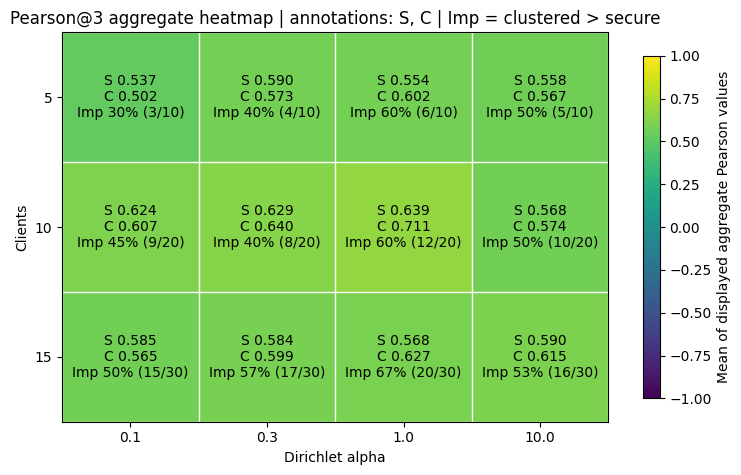

## Pearson@5

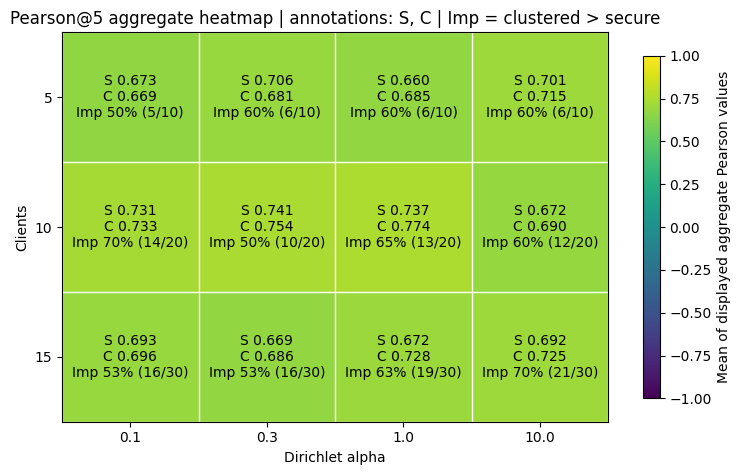

## Pearson@8

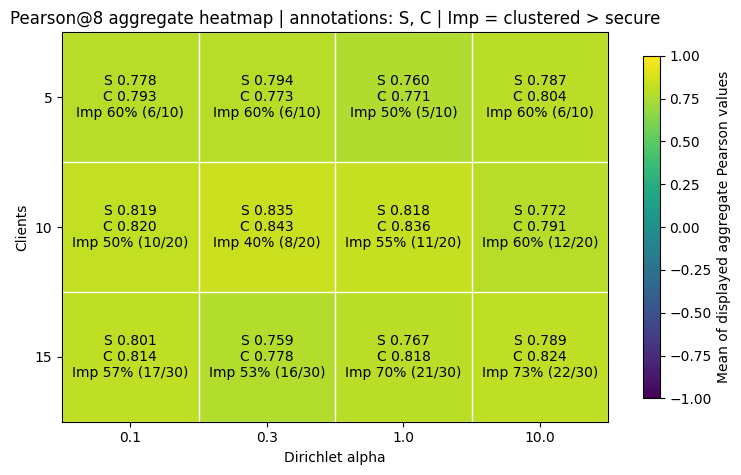

In [4]:
def build_heatmap_payload(
    results: pd.DataFrame,
    improvements: pd.DataFrame,
    metric: str,
    display_modes: list[str],
) -> tuple[pd.DataFrame, pd.DataFrame]:
    if results.empty:
        return pd.DataFrame(dtype=float), pd.DataFrame(dtype=object)

    client_levels = sorted(results["client_count"].unique())
    alpha_rows = (
        results[["alpha", "alpha_label"]]
        .drop_duplicates()
        .sort_values("alpha")
        .reset_index(drop=True)
    )
    alpha_levels = alpha_rows["alpha"].tolist()
    alpha_tick_labels = alpha_rows["alpha_label"].tolist()

    color_df = pd.DataFrame(np.nan, index=client_levels, columns=alpha_levels, dtype=float)
    annotation_df = pd.DataFrame("", index=client_levels, columns=alpha_levels, dtype=object)

    for client_count in client_levels:
        for alpha in alpha_levels:
            cell = results[(results["client_count"] == client_count) & (results["alpha"] == alpha)]
            improvement_row = improvements[
                (improvements["client_count"] == client_count)
                & (improvements["alpha"] == alpha)
                & (improvements["metric"] == metric)
            ]
            values = []
            lines = []
            for mode in display_modes:
                mode_row = cell[cell["mode"] == mode]
                if mode_row.empty:
                    lines.append(f"{MODE_SHORT_LABELS[mode]} --")
                    continue
                value = float(mode_row.iloc[0][metric])
                if np.isnan(value):
                    lines.append(f"{MODE_SHORT_LABELS[mode]} --")
                    continue
                values.append(value)
                lines.append(f"{MODE_SHORT_LABELS[mode]} {value:.3f}")
            if improvement_row.empty:
                lines.append("Imp --")
            else:
                improved_pct = float(improvement_row.iloc[0]["improved_pct"])
                improved_count = int(improvement_row.iloc[0]["improved_count"])
                comparable_client_count = int(improvement_row.iloc[0]["comparable_client_count"])
                if np.isnan(improved_pct) or comparable_client_count == 0:
                    lines.append("Imp --")
                else:
                    lines.append(f"Imp {improved_pct:.0f}% ({improved_count}/{comparable_client_count})")
            color_df.loc[client_count, alpha] = float(np.mean(values)) if values else np.nan
            annotation_df.loc[client_count, alpha] = "\n".join(lines)

    color_df.columns = alpha_tick_labels
    annotation_df.columns = alpha_tick_labels
    return color_df, annotation_df


def text_color_for_value(value: float, norm: mcolors.Normalize, cmap) -> str:
    if np.isnan(value):
        return "#444444"
    red, green, blue, _ = cmap(norm(value))
    luminance = 0.299 * red + 0.587 * green + 0.114 * blue
    return "white" if luminance < 0.5 else "black"


def plot_metric_heatmap(
    results: pd.DataFrame,
    improvements: pd.DataFrame,
    metric: str,
    metric_label: str,
    display_modes: list[str],
) -> None:
    color_df, annotation_df = build_heatmap_payload(results, improvements, metric, display_modes)
    display(Markdown(f"## {metric_label}"))
    if color_df.empty:
        display(Markdown("_No aggregate results were loaded for this metric._"))
        return

    cmap = plt.get_cmap("viridis").copy()
    cmap.set_bad(color="#f3f3f3")
    norm = mcolors.Normalize(vmin=-1.0, vmax=1.0)
    matrix = np.ma.masked_invalid(color_df.to_numpy(dtype=float))

    fig, ax = plt.subplots(figsize=(1.8 + 1.45 * color_df.shape[1], 1.4 + 1.15 * color_df.shape[0]))
    image = ax.imshow(matrix, cmap=cmap, norm=norm, aspect="auto")

    ax.set_xticks(np.arange(color_df.shape[1]))
    ax.set_xticklabels(color_df.columns, rotation=0)
    ax.set_yticks(np.arange(color_df.shape[0]))
    ax.set_yticklabels([str(value) for value in color_df.index])
    ax.set_xlabel("Dirichlet alpha")
    ax.set_ylabel("Clients")
    mode_caption = ", ".join(MODE_SHORT_LABELS[mode] for mode in display_modes)
    ax.set_title(
        f"{metric_label} aggregate heatmap | annotations: {mode_caption} | Imp = {IMPROVEMENT_TARGET_MODE} > {IMPROVEMENT_BASELINE_MODE}"
    )

    ax.set_xticks(np.arange(-0.5, color_df.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, color_df.shape[0], 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=1.0)
    ax.tick_params(which="minor", bottom=False, left=False)

    for row_idx in range(color_df.shape[0]):
        for col_idx in range(color_df.shape[1]):
            annotation = annotation_df.iat[row_idx, col_idx]
            value = color_df.iat[row_idx, col_idx]
            ax.text(
                col_idx,
                row_idx,
                annotation,
                ha="center",
                va="center",
                fontsize=10,
                color=text_color_for_value(value, norm, cmap),
            )

    colorbar = fig.colorbar(image, ax=ax, shrink=0.88)
    colorbar.set_label("Mean of displayed aggregate Pearson values")

    plt.tight_layout()
    plt.show()


for metric, metric_label in METRICS:
    plot_metric_heatmap(aggregated_results, aggregated_clustered_improvements, metric, metric_label, DISPLAY_MODES)


In [5]:
display(Markdown("## Aggregated Results Table"))
aggregated_results.sort_values(["client_count", "alpha", "mode"]).reset_index(drop=True)

display(Markdown("## Clustered Improvement Table"))
aggregated_clustered_improvements.sort_values(["metric", "client_count", "alpha"]).reset_index(drop=True)


## Aggregated Results Table

## Clustered Improvement Table

,client_count,alpha,alpha_label,metric,metric_label,comparison,run_count,improved_count,tied_count,worse_count,comparable_client_count,improved_pct
0,5,0.1,0.1,pearson_at_3,Pearson@3,clustered_over_secure,2,3,1,6,10,30.000000
1,5,0.3,0.3,pearson_at_3,Pearson@3,clustered_over_secure,2,4,2,4,10,40.000000
2,5,1.0,1.0,pearson_at_3,Pearson@3,clustered_over_secure,2,6,2,2,10,60.000000
3,5,10.0,10.0,pearson_at_3,Pearson@3,clustered_over_secure,2,5,2,3,10,50.000000
4,10,0.1,0.1,pearson_at_3,Pearson@3,clustered_over_secure,2,9,3,8,20,45.000000
5,10,0.3,0.3,pearson_at_3,Pearson@3,clustered_over_secure,2,8,6,6,20,40.000000
6,10,1.0,1.0,pearson_at_3,Pearson@3,clustered_over_secure,2,12,0,8,20,60.000000
7,10,10.0,10.0,pearson_at_3,Pearson@3,clustered_over_secure,2,10,1,9,20,50.000000
8,15,0.1,0.1,pearson_at_3,Pearson@3,clustered_over_secure,2,15,0,15,30,50.000000
9,15,0.3,0.3,pearson_at_3,Pearson@3,clustered_over_secure,2,17,1,12,30,56.666667


In [6]:
# display(Markdown("## Save Snapshot for Before/After Comparison"))

# display(Markdown(
#     f"Snapshot label: `{SNAPSHOT_LABEL}`  \
# Snapshot root: `{RESULT_SNAPSHOT_ROOT}`"
# ))

# snapshot_paths = save_result_snapshot(
#     snapshot_root=RESULT_SNAPSHOT_ROOT,
#     snapshot_label=SNAPSHOT_LABEL,
#     run_results=run_results,
#     aggregated_results=aggregated_results,
#     raw_client_results=raw_client_results,
#     clustered_improvements=clustered_improvements,
#     aggregated_clustered_improvements=aggregated_clustered_improvements,
# )

# snapshot_path_frame = pd.DataFrame(
#     {"artifact": list(snapshot_paths.keys()), "path": list(snapshot_paths.values())}
# )

# display(Markdown(
#     f"Saved aggregate and raw client-score snapshots to `{snapshot_paths['snapshot_dir']}`."
# ))
# snapshot_path_frame


## Comparison with older implementation

Comparing current run results against snapshot `baseline_before_updated_recommender_training_20260505T144105Z` from `notebooks/artifacts/recommender_result_snapshots`.

## Pearson@3

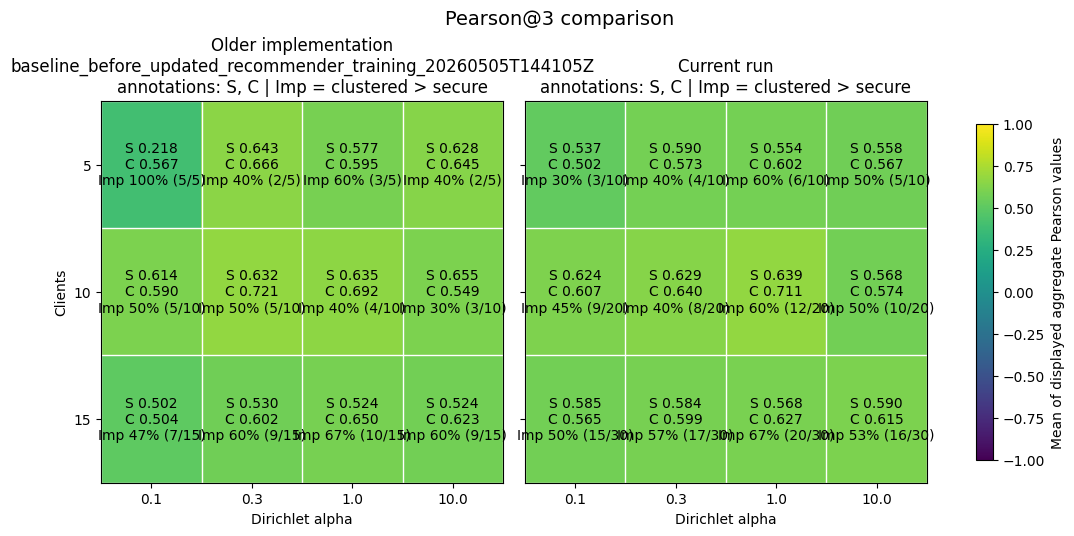

## Pearson@5

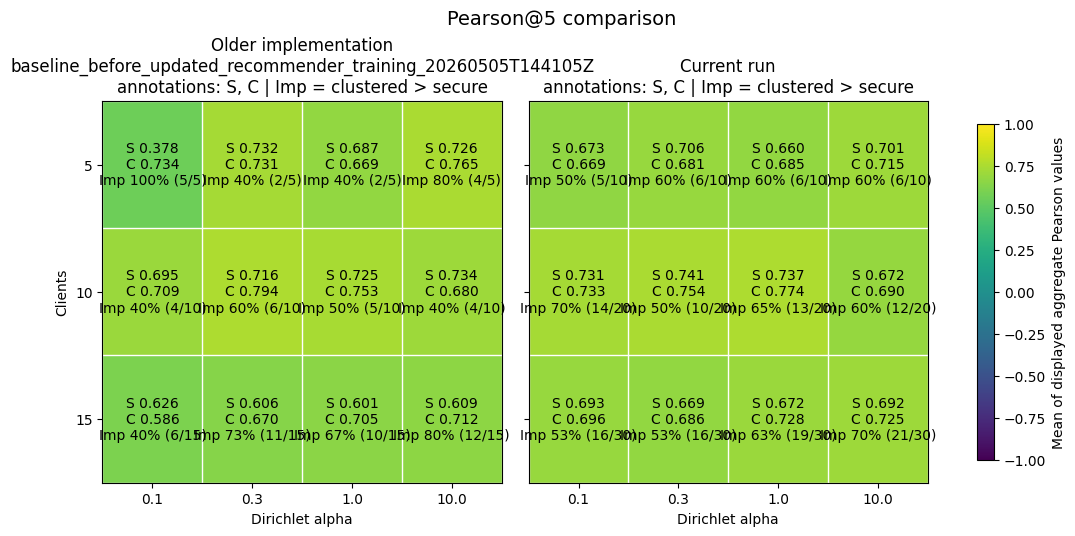

## Pearson@8

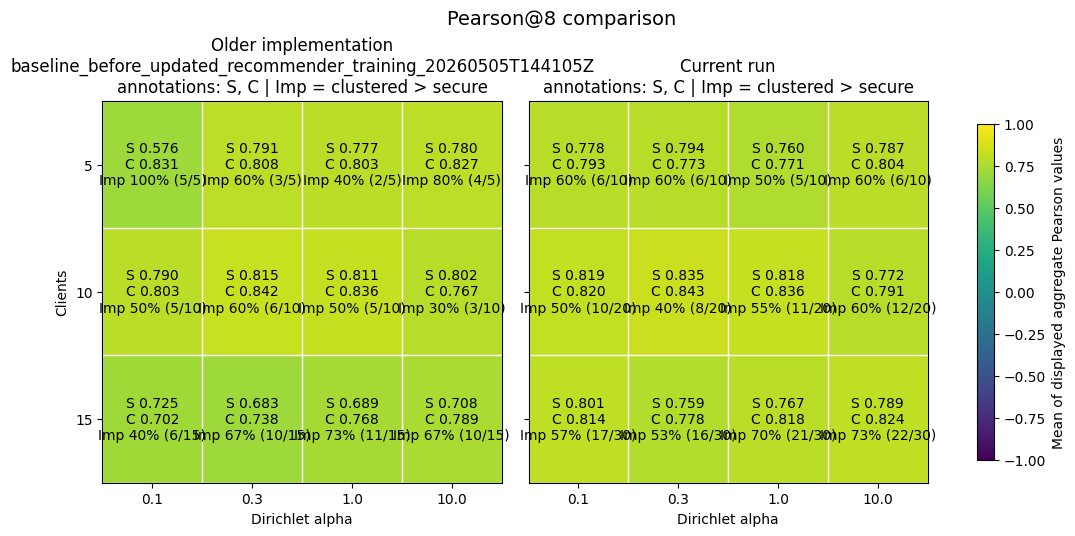

In [7]:
def load_snapshot_tables(snapshot_dir: Path) -> tuple[pd.DataFrame, pd.DataFrame]:
    aggregated_path = snapshot_dir / "aggregated_results.csv"
    improvements_path = snapshot_dir / "aggregated_clustered_improvements.csv"
    if not aggregated_path.exists() or not improvements_path.exists():
        missing = [
            str(path)
            for path in [aggregated_path, improvements_path]
            if not path.exists()
        ]
        raise FileNotFoundError("Missing snapshot artifacts: " + ", ".join(missing))
    return pd.read_csv(aggregated_path), pd.read_csv(improvements_path)


def _dedupe_heatmap_frame(frame: pd.DataFrame, *, fill_value=np.nan) -> pd.DataFrame:
    if frame.empty:
        return frame.copy()
    deduped = frame.copy()
    deduped.index = pd.Index(deduped.index)
    deduped.columns = pd.Index([str(column) for column in deduped.columns])
    deduped = deduped.loc[~deduped.index.duplicated(keep="first")]
    deduped = deduped.loc[:, ~deduped.columns.duplicated(keep="first")]
    if fill_value == "":
        return deduped.fillna("")
    return deduped


def _shared_alpha_labels(*results_frames: pd.DataFrame) -> list[str]:
    alpha_parts: list[pd.DataFrame] = []
    for results in results_frames:
        if results.empty or "alpha_label" not in results.columns:
            continue
        alpha_part = results[["alpha_label"]].copy()
        if "alpha" in results.columns:
            alpha_part["alpha_numeric"] = pd.to_numeric(results["alpha"], errors="coerce")
        else:
            alpha_part["alpha_numeric"] = np.nan
        alpha_part["alpha_label"] = alpha_part["alpha_label"].astype(str)
        missing_numeric = alpha_part["alpha_numeric"].isna()
        alpha_part.loc[missing_numeric, "alpha_numeric"] = pd.to_numeric(
            alpha_part.loc[missing_numeric, "alpha_label"], errors="coerce"
        )
        alpha_parts.append(alpha_part)

    if not alpha_parts:
        return []

    alpha_rows = pd.concat(alpha_parts, ignore_index=True)
    alpha_rows = alpha_rows.sort_values(
        ["alpha_numeric", "alpha_label"],
        na_position="last",
        kind="stable",
    )
    alpha_rows = alpha_rows.drop_duplicates(subset=["alpha_label"], keep="first")
    return alpha_rows["alpha_label"].tolist()


def render_heatmap_axis(
    ax,
    color_df: pd.DataFrame,
    annotation_df: pd.DataFrame,
    title: str,
    display_modes: list[str],
    norm: mcolors.Normalize,
    cmap,
):
    if color_df.empty:
        ax.axis("off")
        ax.set_title(f"{title}\nNo data")
        return None

    matrix = np.ma.masked_invalid(color_df.to_numpy(dtype=float))
    image = ax.imshow(matrix, cmap=cmap, norm=norm, aspect="auto", interpolation="nearest")

    ax.set_xticks(np.arange(color_df.shape[1]))
    ax.set_xticklabels([str(column) for column in color_df.columns], rotation=0)
    ax.set_yticks(np.arange(color_df.shape[0]))
    ax.set_yticklabels([str(value) for value in color_df.index])
    ax.set_xlabel("Dirichlet alpha")
    ax.set_ylabel("Clients")
    ax.set_xlim(-0.5, color_df.shape[1] - 0.5)
    ax.set_ylim(color_df.shape[0] - 0.5, -0.5)

    mode_caption = ", ".join(MODE_SHORT_LABELS[mode] for mode in display_modes)
    ax.set_title(
        f"{title}\nannotations: {mode_caption} | Imp = {IMPROVEMENT_TARGET_MODE} > {IMPROVEMENT_BASELINE_MODE}"
    )

    ax.set_xticks(np.arange(-0.5, color_df.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, color_df.shape[0], 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=1.0)
    ax.tick_params(which="minor", bottom=False, left=False)

    for row_idx in range(color_df.shape[0]):
        for col_idx in range(color_df.shape[1]):
            annotation = annotation_df.iat[row_idx, col_idx]
            value = color_df.iat[row_idx, col_idx]
            if pd.isna(value) or not str(annotation).strip():
                continue
            ax.text(
                col_idx,
                row_idx,
                annotation,
                ha="center",
                va="center",
                fontsize=10,
                color=text_color_for_value(value, norm, cmap),
            )

    return image


def align_heatmap_payloads(
    left_results: pd.DataFrame,
    right_results: pd.DataFrame,
    left_color_df: pd.DataFrame,
    left_annotation_df: pd.DataFrame,
    right_color_df: pd.DataFrame,
    right_annotation_df: pd.DataFrame,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    client_levels = sorted(
        set(left_results.get("client_count", pd.Series(dtype=int)).dropna().astype(int))
        | set(right_results.get("client_count", pd.Series(dtype=int)).dropna().astype(int))
    )
    alpha_labels = _shared_alpha_labels(left_results, right_results)

    left_color_df = _dedupe_heatmap_frame(left_color_df).reindex(index=client_levels, columns=alpha_labels)
    left_annotation_df = _dedupe_heatmap_frame(left_annotation_df, fill_value="").reindex(
        index=client_levels, columns=alpha_labels, fill_value=""
    )
    right_color_df = _dedupe_heatmap_frame(right_color_df).reindex(index=client_levels, columns=alpha_labels)
    right_annotation_df = _dedupe_heatmap_frame(right_annotation_df, fill_value="").reindex(
        index=client_levels, columns=alpha_labels, fill_value=""
    )
    return left_color_df, left_annotation_df, right_color_df, right_annotation_df


def plot_metric_heatmap_comparison(
    older_results: pd.DataFrame,
    older_improvements: pd.DataFrame,
    current_results: pd.DataFrame,
    current_improvements: pd.DataFrame,
    metric: str,
    metric_label: str,
    display_modes: list[str],
    older_title: str,
    current_title: str,
) -> None:
    older_color_df, older_annotation_df = build_heatmap_payload(
        older_results, older_improvements, metric, display_modes
    )
    current_color_df, current_annotation_df = build_heatmap_payload(
        current_results, current_improvements, metric, display_modes
    )

    if older_color_df.empty and current_color_df.empty:
        display(Markdown(f"## {metric_label}"))
        display(Markdown("_No comparison data was available for this metric._"))
        return

    (
        older_color_df,
        older_annotation_df,
        current_color_df,
        current_annotation_df,
    ) = align_heatmap_payloads(
        older_results,
        current_results,
        older_color_df,
        older_annotation_df,
        current_color_df,
        current_annotation_df,
    )

    cmap = plt.get_cmap("viridis").copy()
    cmap.set_bad(color="#f3f3f3")
    norm = mcolors.Normalize(vmin=-1.0, vmax=1.0)

    display(Markdown(f"## {metric_label}"))
    fig, axes = plt.subplots(
    ncols=2,
    sharey=True,
    figsize=(
        3.8 + 1.6 * max(1, older_color_df.shape[1]),
        1.8 + 1.15 * max(1, older_color_df.shape[0]),
    ),
    constrained_layout=True,
    )
    
    older_image = render_heatmap_axis(
        axes[0], older_color_df, older_annotation_df, older_title, display_modes, norm, cmap
    )
    current_image = render_heatmap_axis(
        axes[1], current_color_df, current_annotation_df, current_title, display_modes, norm, cmap
    )
    
    axes[1].set_ylabel("")
    
    mappable = current_image if current_image is not None else older_image
    
    colorbar = fig.colorbar(
        mappable,
        ax=axes.ravel().tolist(),
        shrink=0.88,
    )
    colorbar.set_label("Mean of displayed aggregate Pearson values")
    
    fig.suptitle(f"{metric_label} comparison", fontsize=14)
    plt.show()


current_snapshot_dir = None
if "snapshot_paths" in globals() and snapshot_paths.get("snapshot_dir"):
    current_snapshot_dir = Path(snapshot_paths["snapshot_dir"])

comparison_snapshot_dirs = sorted(
    path
    for path in RESULT_SNAPSHOT_ROOT.glob(f"{SNAPSHOT_LABEL}_*")
    if path.is_dir() and path != current_snapshot_dir
)

if not comparison_snapshot_dirs:
    display(Markdown("_No older snapshot was found under `notebooks/artifacts/recommender_result_snapshots`._"))
else:
    older_snapshot_dir = comparison_snapshot_dirs[-1]
    older_aggregated_results, older_aggregated_clustered_improvements = load_snapshot_tables(older_snapshot_dir)

    display(Markdown(
        f"Comparing current run results against snapshot `{older_snapshot_dir.name}` from `notebooks/artifacts/recommender_result_snapshots`."
    ))

    for metric, metric_label in METRICS:
        plot_metric_heatmap_comparison(
            older_aggregated_results,
            older_aggregated_clustered_improvements,
            aggregated_results,
            aggregated_clustered_improvements,
            metric,
            metric_label,
            DISPLAY_MODES,
            older_title=f"Older implementation\n{older_snapshot_dir.name}",
            current_title="Current run",
        )
